In [2]:
%load_ext autoreload
%autoreload 2
from scripts.ingestion import *
from scripts.data_qc import *
from scripts.poke_detection import *


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

In [3]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/linearity_test_ch5"

session_index = build_sessions_index(data_dir)
# session_index.write_csv("linearity_test_session_index.csv")

In [4]:
# extract the z-axis displacements
dzs = session_index["notes"].to_list()
dzs = [re.search(r"dz=(\d+)", note).group(1) for note in dzs]
dz_all = [int(dz) for dz in dzs]
dz_all = np.array(dz_all)
dz_all.sort()

In [5]:
# check sign of the signal
dz = 260

query = pl.col("notes").str.contains(f"dz={dz}")

filtered = session_index.filter(query).to_dicts()[0]
fs = filtered["fs_hz"]
N_cap = filtered["saved_sweeps"]

pdf = load_session_pandas(filtered, flip=True)
# s0, s1 = 20000, 25000
# t0, t1 = s0 / fs, s1 / fs
# times = np.linspace(t0, t1, len(pdf["CH5"][s0:s1]))
# plt.plot(times, pdf["CH5"][s0:s1])


In [6]:
min_height = 40 if (dz < 150) else 50
n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500, CHS=["CH5"])

poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=100.0)
force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
print(f"dz={dz}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")

# features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=50.0, pre_ms=50.0, post_ms=100.0)

# peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.98)

dz=260, detected 10 pokes, force peaks: 10


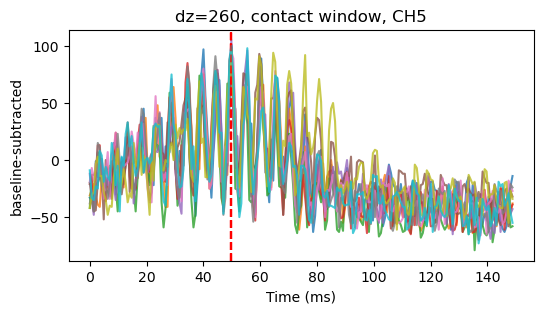

Text(0.5, 1.0, 'Contact window, CH5')

In [7]:
f = plot_poke_windows(poke_windows, fs, ch="CH5", n=len(poke_windows),
                      title=f"dz={dz}, contact window, CH5")
ax = f.axes[0]
ax.set_title("Contact window, CH5")

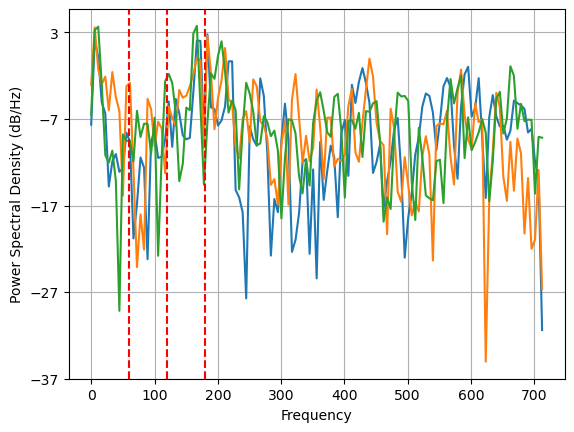

In [36]:
# for poke_window in poke_windows:

for j in range(3):
    _ = plt.psd(poke_windows[j]["window"]["CH1"], Fs=fs)

for i in range(1,4):
    plt.axvline(i*60, color="red", linestyle="--")

## for all dz

In [9]:
feature_name = "pk98"
features_all = []
features_norm_all = []

dz_valid = dz_all[dz_all >= 100]
for dz in dz_valid:
    query = pl.col("notes").str.contains(f"dz={dz}")

    filtered = session_index.filter(query)
    filtered = filtered.sort("timestamp", descending=True)
    filtered = filtered.to_dicts()[0]

    fs = filtered["fs_hz"]
    N_cap = filtered["saved_sweeps"]
    pdf = load_session_pandas(filtered, flip=True)

    min_height = 40 if (dz < 150) else 50
    n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500, CHS=["CH5"])

    poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=100.0)

    force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
    assert(len(force_peaks) == len(final_peaks)), f"Force peak count {len(force_peaks)} does not match poke peak count {len(final_peaks)}"
    print(f"dz={dz}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")

    features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=50.0, pre_ms=50.0, post_ms=75.0)

    peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.98)

    # validate that the peaks are real
    # plt.figure()
    # plt.plot(mixed_pos)
    # plt.plot(final_peaks, mixed_pos[final_peaks], "rx")
    # plt.title(f"disp:{dz} microns channel 5 detected {len(final_peaks)} pokes")

    # plt.figure()
    # plt.plot(F)
    # plt.plot(force_peaks, F[force_peaks], "rx")
    # plt.title(f"force channel detected {len(force_peaks)} pokes")

    # extract features
    features["force_peak"] = peak_fs
    feature_cols = features.columns.drop("force_peak")
    features["dz"] = dz
    features_all.append(features)

    df_norm = features.copy()
    df_norm[feature_cols] = df_norm[feature_cols].div(df_norm["force_peak"], axis=0)

    features_norm_all.append(df_norm)
    
    # eng_cols = [f"{ch}_{feature_name}" for ch in CHS]
    # eng_long = df_norm[eng_cols].melt(var_name="channel", value_name="energy")
    # plt.figure(figsize=(7, 4))
    # sns.boxplot(data=eng_long, x="channel", y="energy")
    # plt.title(f"CH1-CH5 energy, dz={dz} microns")
    # plt.tight_layout()

all_features_df = pd.concat(features_all, ignore_index=True)
all_features_norm_df = pd.concat(features_norm_all, ignore_index=True)

dz=100, detected 10 pokes, force peaks: 10
dz=150, detected 10 pokes, force peaks: 10
dz=160, detected 10 pokes, force peaks: 10
dz=170, detected 10 pokes, force peaks: 10
dz=180, detected 10 pokes, force peaks: 10
dz=180, detected 10 pokes, force peaks: 10
dz=190, detected 10 pokes, force peaks: 10
dz=190, detected 10 pokes, force peaks: 10
dz=200, detected 10 pokes, force peaks: 10
dz=200, detected 10 pokes, force peaks: 10
dz=210, detected 10 pokes, force peaks: 10
dz=220, detected 10 pokes, force peaks: 10
dz=230, detected 10 pokes, force peaks: 10
dz=240, detected 10 pokes, force peaks: 10
dz=250, detected 10 pokes, force peaks: 10
dz=260, detected 10 pokes, force peaks: 10
dz=270, detected 10 pokes, force peaks: 10
dz=280, detected 10 pokes, force peaks: 10
dz=290, detected 10 pokes, force peaks: 10
dz=300, detected 10 pokes, force peaks: 10


<Axes: xlabel='dz', ylabel='CH5_p2p99'>

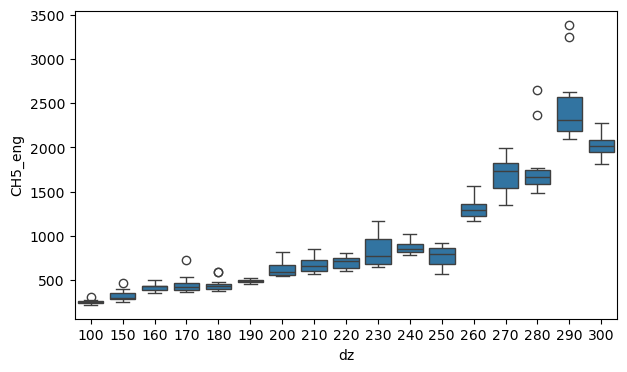

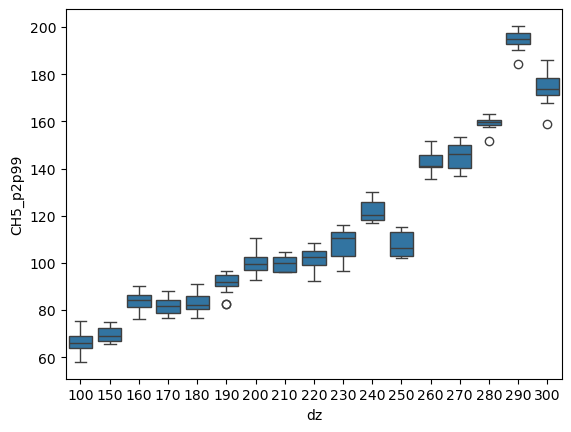

In [10]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=all_features_df, x="dz", y="CH5_eng")
plt.figure()
sns.boxplot(data=all_features_df, x="dz", y="CH5_p2p99")

In [11]:
# save to csv
all_features_df.to_csv("linearity_test_features.csv", index=False)

<Axes: xlabel='dz', ylabel='force_peak'>

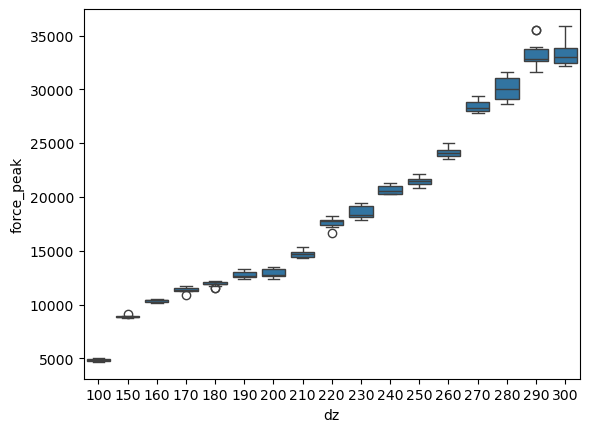

In [12]:
sns.boxplot(data=all_features_df, x="dz", y="force_peak")

In [13]:
import statsmodels.api as sm
from scipy.stats import pearsonr

r = 0.963, p = 3.812e-114


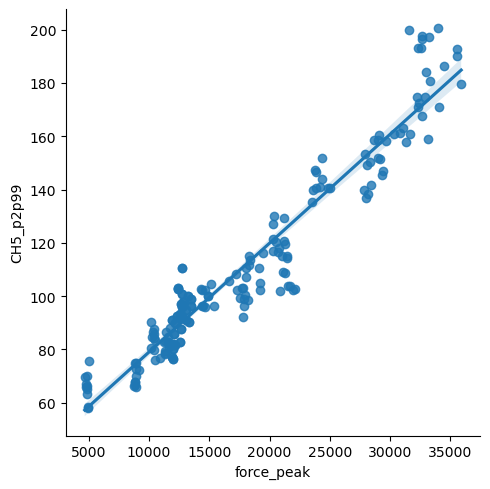

In [46]:
ch = 5
feature_name = "p2p99"
sns.lmplot(data=all_features_df, x="force_peak", y=f"CH{ch}_{feature_name}")
r, p = pearsonr(
    all_features_df["force_peak"],
    all_features_df[f"CH{ch}_{feature_name}"])

print(f"r = {r:.3f}, p = {p:.3e}")

In [62]:
X = all_features_df["force_peak"]
y = all_features_df["CH5_p2p99"]

X = sm.add_constant(X)  # adds intercept
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              CH5_p2p99   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     2493.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          3.81e-114
Time:                        13:41:44   Log-Likelihood:                -732.11
No. Observations:                 200   AIC:                             1468.
Df Residuals:                     198   BIC:                             1475.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.1515      1.592     23.967      0.0

In [50]:
from constants import Z_FORCE_SENSOR_TO_NEWTON

In [53]:
# pick only CHx_p2p99 columns
p2p_cols = all_features_df.filter(regex=r"^CH\d+_p2p99$").columns

# keep any metadata columns you want to carry through
id_cols = [c for c in ["dz", "force_peak"] if c in all_features_df.columns]

p2p_long = all_features_df.melt(
    id_vars=id_cols,
    value_vars=p2p_cols,
    var_name="ch_feature",
    value_name="p2p99",
)

# extract channel (as int). Use .astype(str) if you prefer "1","2",...
p2p_long["Channel"] = p2p_long["ch_feature"].str.extract(r"^CH(\d+)_p2p99$").astype(int)

# optional: drop old combined name
p2p_long = p2p_long.drop(columns="ch_feature")

p2p_long["force_peak_newton"] = p2p_long["force_peak"] / Z_FORCE_SENSOR_TO_NEWTON

Text(37.04877829218107, 0.5, 'P2P99')

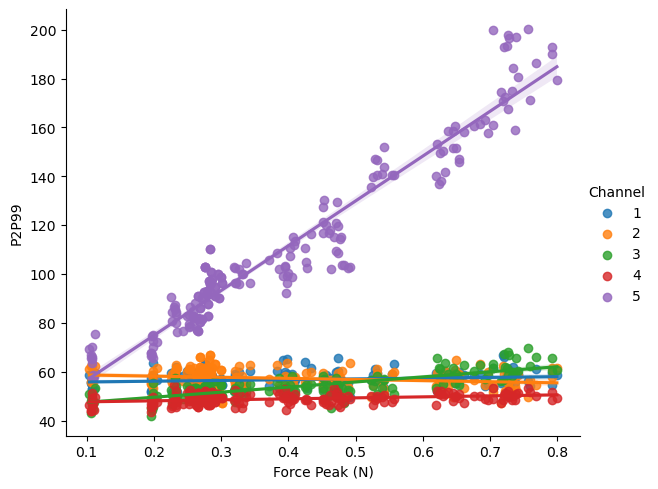

In [55]:
sns.lmplot(data=p2p_long, x="force_peak_newton", y="p2p99", hue="Channel", aspect=1.2)

plt.xlabel("Force Peak (N)")
plt.ylabel("P2P99")

### Predict force peaks (N) from sensor features

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [63]:
y = all_features_df["force_peak"] / Z_FORCE_SENSOR_TO_NEWTON
X = all_features_df["CH5_p2p99"].values.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R^2: {r2:.3f}", f"coef: {model.coef_[0]:.3f}", f"intercept: {model.intercept_:.3f}")

R^2: 0.926 coef: 0.005 intercept: -0.164
